# Customer Churn Prediction

## Problem Statement
Predict whether a telecom customer will churn (leave) or stay using historical customer data.

## 1. Data Understanding
The dataset includes demographics, services used, billing details, and tenure.

Target:
- Churn (1 = Yes, 0 = No)

In [66]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Data Preprocessing
- Dropped customerID (non-informative)
- Converted TotalCharges to numeric and handled missing values
- Encoded categorical variables using one-hot encoding
- Scaled numerical features

In [68]:
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [69]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [70]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [71]:
df = pd.get_dummies(df, drop_first=True)
df = df.astype(int)

In [72]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [73]:
from sklearn.preprocessing import StandardScaler

Scaler = StandardScaler()
X_Scaled = Scaler.fit_transform(X)

## 3. Model Training
- Logistic Regression (baseline)
- Decision Tree (comparison)

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_Scaled, y, test_size=0.2, random_state=42
)

In [75]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [76]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=3)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Model Comparison

This chart compares the performance of Logistic Regression and Decision Tree models.

It helps identify which model provides better accuracy for predicting customer churn.

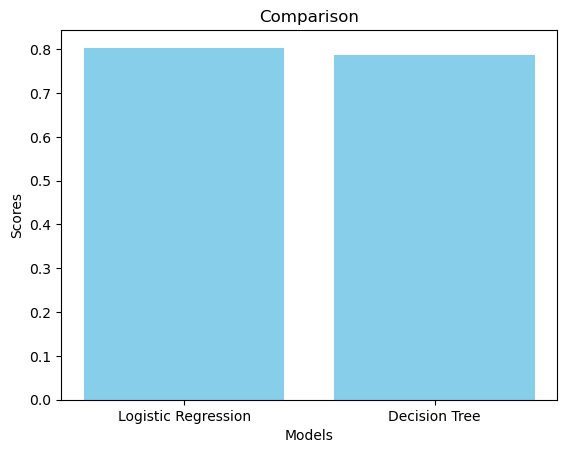

In [77]:
models = ['Logistic Regression', 'Decision Tree']
scores = [lr_model.score(X_train, y_train),
         dt_model.score(X_train, y_train)]

plt.figure()
plt.bar(models, scores, color='skyblue')
plt.title('Comparison')
plt.xlabel('Models')
plt.ylabel('Scores')
plt.show()

## 4. Evaluation
- Accuracy, Precision, Recall, F1-score
- Confusion Matrix

In [78]:
y_pred = lr_model.predict(X_test)

In [79]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



### Confusion Matrix

This matrix shows how well the model predicts churn.

It highlights correct predictions and errors, helping to understand where the model is making mistakes.

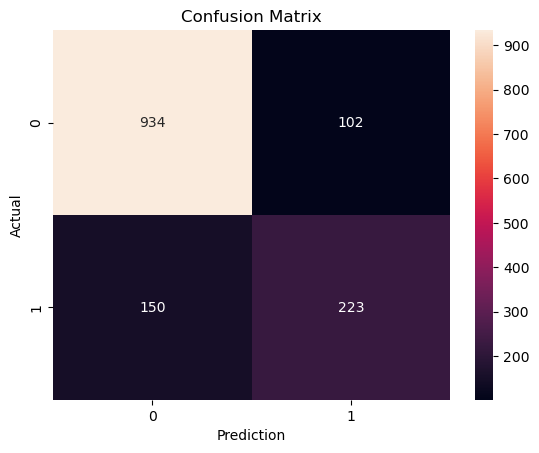

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

### Feature Importance

This plot shows how different features influence churn prediction.

Features with higher impact values play a more significant role in determining whether a customer will churn.

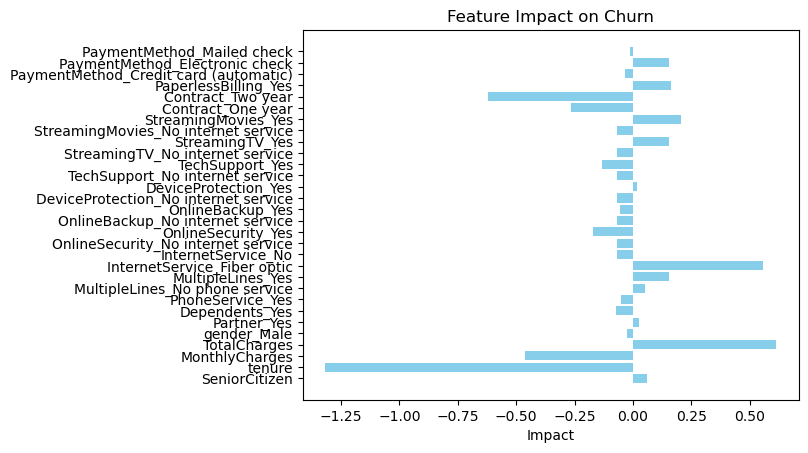

In [81]:
importance = lr_model.coef_[0]

plt.figure()
plt.barh(X.columns, importance, color='skyblue')
plt.title('Feature Impact on Churn')
plt.xlabel('Impact')
plt.show()

In [82]:
new_data = pd.DataFrame([X.iloc[0]], columns=X.columns)
new_data_scaled = Scaler.transform(new_data)

print("Prediction:", lr_model.predict(new_data_scaled))

Prediction: [1]


### Churn Distribution

This plot shows the number of customers who stayed versus those who churned.

It helps identify class imbalance in the dataset, which is important for evaluating model performance.

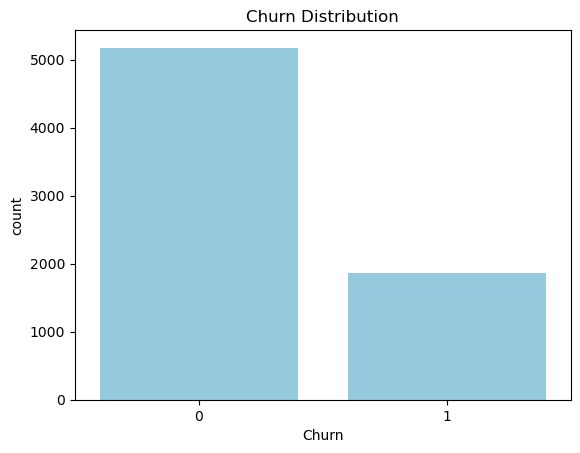

In [83]:
sns.countplot(x=y, color='skyblue')
plt.title('Churn Distribution')
plt.show()

### Tenure vs Churn

This boxplot compares customer tenure for churned and non-churned users.

It shows that customers with shorter tenure are more likely to churn, indicating that early engagement is crucial for retention.

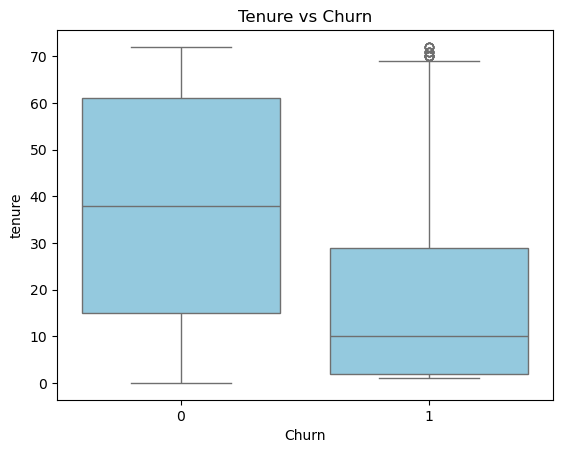

In [84]:
sns.boxplot(x=y, y=df['tenure'], color='skyblue')
plt.title('Tenure vs Churn')
plt.show()

## 5. Insights
- High monthly charges increase churn risk
- Longer tenure reduces churn
- Contract type strongly impacts churn

## 6. Conclusion
The model can help businesses identify high-risk customers and take retention actions.

In [87]:
import pickle

pickle.dump(lr_model, open("model.pkl", "wb"))
pickle.dump(Scaler, open("scaler.pkl", "wb"))